Loading configuration and dataset...
Dataset Loaded! Total samples: 278


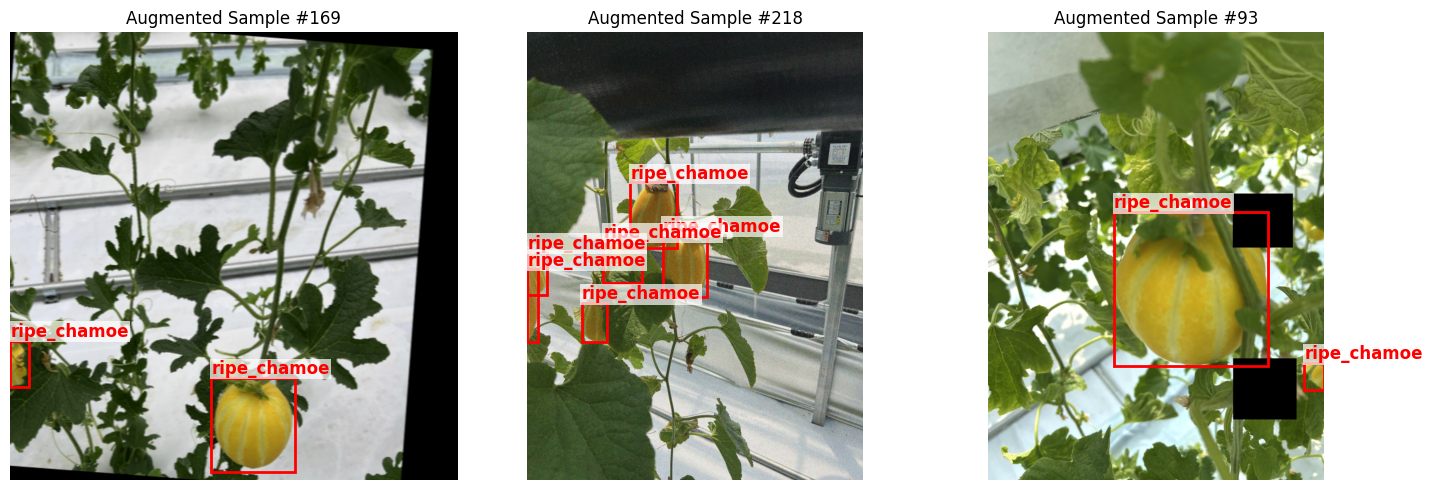

In [13]:
"""
데이터 증강(Augmentation)이 잘 적용되었는지 시각적으로 확인하는 스크립트입니다.
"""

import random
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

from configs.config import Config
from src.dataset import create_dataset
from src.model import load_processor

def denormalize(tensor_img):
    """
    Hugging Face Processor가 텐서로 변환하고 정규화(Normalize)한 이미지를
    다시 사람이 눈으로 볼 수 있는 원래의 이미지 배열로 되돌립니다.
    """
    # ImageNet의 기본 평균과 표준편차
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    
    # (C, H, W) 포맷을 matplotlib이 읽을 수 있는 (H, W, C)로 변경
    img = tensor_img.permute(1, 2, 0).numpy()
    
    # 정규화 해제: (img * std) + mean
    img = std * img + mean
    img = np.clip(img, 0, 1) # 0~1 사이 값으로 안전하게 자르기
    return img

def main():
    print("Loading configuration and dataset...")
    data_cfg = Config.load_data_config()
    processor = load_processor(Config.MODEL_CHECKPOINT)
    
    # config.py에 정의한 증강 파이프라인 로드
    train_transform = Config.get_train_transforms()

    # Train 데이터셋 생성 (증강 적용)
    train_dataset = create_dataset(
        data_cfg=data_cfg, 
        split='train', 
        processor=processor,
        transform=train_transform
    )

    print(f"Dataset Loaded! Total samples: {len(train_dataset)}")

    # 랜덤하게 3개의 이미지 인덱스 뽑기
    indices = random.sample(range(len(train_dataset)), 3)
    
    fig, axes = plt.subplots(1, 3, figsize=(15, 5))
    
    for ax, idx in zip(axes, indices):
        sample = train_dataset[idx]
        img_tensor = sample["pixel_values"]
        target = sample["labels"]
        
        # 1. 이미지 복원 (Denormalization)
        img = denormalize(img_tensor)
        h, w, _ = img.shape
        
        ax.imshow(img)
        ax.axis('off')
        ax.set_title(f"Augmented Sample #{idx}")
        
        # 2. Bounding Box 그리기
        # HF 모델(DETR, YOLOS 등)은 박스를 정규화된 [중심x, 중심y, 너비, 높이]로 반환합니다.
        boxes = target["boxes"]
        classes = target["class_labels"]
        
        for box, cls in zip(boxes, classes):
            cx, cy, bw, bh = box.tolist()
            
            # 0~1 사이로 정규화된 좌표를 실제 픽셀 크기로 복원
            abs_cx, abs_cy = cx * w, cy * h
            abs_w, abs_h = bw * w, bh * h
            
            # 중심 좌표를 좌상단(x_min, y_min) 좌표로 변환
            x_min = abs_cx - (abs_w / 2)
            y_min = abs_cy - (abs_h / 2)
            
            # 빨간색 사각형 그리기
            rect = patches.Rectangle(
                (x_min, y_min), abs_w, abs_h, 
                linewidth=2, edgecolor='red', facecolor='none'
            )
            ax.add_patch(rect)
            
            # 클래스 이름 텍스트 추가
            label_name = train_dataset.id2label.get(cls.item(), str(cls.item()))
            ax.text(x_min, y_min - 8, label_name, color='red', fontsize=12, weight='bold', 
                    bbox=dict(facecolor='white', alpha=0.7, edgecolor='none', pad=1))

    plt.tight_layout()
    plt.show()

if __name__ == "__main__":
    main()